In [43]:
import sys
import subprocess
import importlib

required = ["torch", "transformers", "datasets", "accelerate", "tqdm"]
for pkg in required:
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm.auto import tqdm

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch version: 2.10.0+cu130
CUDA available: True


In [44]:
# Load TinyStories validation split and the model
MODEL_ID = "SauravP97/tiny-stories-3M"
# MODEL_ID = "jacksuuuu/tinystories"
TOKENIZER_ID_FALLBACK = "EleutherAI/gpt-neo-125M"
DATASET_ID = "roneneldan/TinyStories"

# Keep evaluation reasonably fast; increase for more stable metrics
EVAL_SAMPLES = 200
MAX_LENGTH = 512

dataset = load_dataset(DATASET_ID, split="validation")
print("Total validation examples:", len(dataset))

def load_causal_lm_compat(model_name_or_path, trust_remote_code=True):
    try:
        return AutoModelForCausalLM.from_pretrained(
            model_name_or_path,
            trust_remote_code=trust_remote_code,
        )
    except AttributeError as e:
        if "all_tied_weights_keys" not in str(e):
            raise

        from transformers import modeling_utils

        original_adjust = modeling_utils.PreTrainedModel._adjust_tied_keys_with_tied_pointers

        def _safe_adjust(self, missing_keys):
            if not hasattr(self, "all_tied_weights_keys"):
                self.all_tied_weights_keys = {}
            return original_adjust(self, missing_keys)

        modeling_utils.PreTrainedModel._adjust_tied_keys_with_tied_pointers = _safe_adjust

        return AutoModelForCausalLM.from_pretrained(
            model_name_or_path,
            trust_remote_code=trust_remote_code,
        )

# Some fine-tuned repos don't include a usable tokenizer; fallback if tokenization is empty
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=False, trust_remote_code=True)
probe = tokenizer("hello world", return_tensors="pt")["input_ids"]
if probe.shape[1] == 0:
    print(f"Tokenizer from {MODEL_ID} returned 0 tokens; using fallback {TOKENIZER_ID_FALLBACK}")
    tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_ID_FALLBACK, use_fast=False)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = load_causal_lm_compat(MODEL_ID, trust_remote_code=True)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

print("Model loaded on:", device)
print("Evaluating on samples:", EVAL_SAMPLES)
print("Tokenizer class:", tokenizer.__class__.__name__)

Total validation examples: 21990
Tokenizer from SauravP97/tiny-stories-3M returned 0 tokens; using fallback EleutherAI/gpt-neo-125M


Loading weights:   0%|          | 0/108 [00:00<?, ?it/s]

Model loaded on: cuda
Evaluating on samples: 200
Tokenizer class: GPT2Tokenizer


In [45]:
# Evaluate next-token accuracy and perplexity on TinyStories validation subset
sampled = dataset.select(range(min(EVAL_SAMPLES, len(dataset))))

correct = 0
total = 0
nll_sum = 0.0
token_count = 0
skipped = 0

for ex in tqdm(sampled, desc="Evaluating"):
    text = ex["text"]
    enc = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
        add_special_tokens=False,
    )
    input_ids = enc["input_ids"]

    if input_ids.shape[1] < 2:
        skipped += 1
        continue

    input_ids = input_ids.to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids)
        logits = outputs.logits[:, :-1, :]  # predict next token
        labels = input_ids[:, 1:]           # target next token

        preds = torch.argmax(logits, dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.numel()

        log_probs = torch.log_softmax(logits, dim=-1)
        target_log_probs = log_probs.gather(-1, labels.unsqueeze(-1)).squeeze(-1)
        nll_sum += (-target_log_probs).sum().item()
        token_count += labels.numel()

next_token_accuracy = correct / total if total else float("nan")
avg_nll = nll_sum / token_count if token_count else float("nan")
perplexity = float(torch.exp(torch.tensor(avg_nll))) if token_count else float("nan")

print(f"Next-token accuracy: {next_token_accuracy:.4f}")
print(f"Perplexity: {perplexity:.2f}")
print(f"Evaluated tokens: {total}")
print(f"Skipped examples (too short/empty after tokenization): {skipped}")

Evaluating:   0%|          | 0/200 [00:00<?, ?it/s]

Next-token accuracy: 0.5532
Perplexity: 6.71
Evaluated tokens: 37287
Skipped examples (too short/empty after tokenization): 0


In [46]:
# Debug checks for NaN/eval and generation failures
print('Dataset columns:', dataset.column_names)
for idx in [0, 1, 2]:
    t = dataset[idx]['text']
    ids = tokenizer(t, return_tensors='pt', truncation=True, max_length=MAX_LENGTH, add_special_tokens=False)['input_ids']
    print(f'sample {idx}: chars={len(t)}, tokens={ids.shape[1]}')

for p in [
    'Once upon a time, there was a little rabbit named Momo who',
    'Lina found a shiny key under her bed and',
]:
    p_ids = tokenizer(p, return_tensors='pt')['input_ids']
    print('prompt tokens:', p_ids.shape[1], 'prompt preview:', p[:40])

Dataset columns: ['text']
sample 0: chars=349, tokens=82
sample 1: chars=1201, tokens=303
sample 2: chars=509, tokens=131
prompt tokens: 14 prompt preview: Once upon a time, there was a little rab
prompt tokens: 10 prompt preview: Lina found a shiny key under her bed and


In [47]:
# Generate new TinyStories-style outputs
prompts = [
    "Once upon a time, there was a little rabbit named Momo who",
    "Lina found a shiny key under her bed and",
    "Tom and his dad planted a tiny seed in the garden. The next morning,",
]

gen_kwargs = dict(
    max_new_tokens=120,
    do_sample=True,
    temperature=0.9,
    top_p=0.95,
    repetition_penalty=1.1,
    pad_token_id=tokenizer.eos_token_id,
    use_cache=False,
)

for i, prompt in enumerate(prompts, start=1):
    inputs = tokenizer(prompt, return_tensors="pt")
    if inputs["input_ids"].shape[1] == 0:
        print(f"\n--- Story {i} ---")
        print("Skipped: tokenizer produced empty input for this prompt.")
        continue

    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        output_ids = model.generate(**inputs, **gen_kwargs)
    generated = tokenizer.decode(output_ids[0], skip_special_tokens=True)

    print(f"\n--- Story {i} ---")
    print(generated)



--- Story 1 ---
Once upon a time, there was a little rabbit named Momo who loved to play in the forest. One day, while walking in the woods, she saw a tall tree with a lock on her finger. It had lots of leaves and flowers in its branches. 

The big lion decided to pick a closer look and see that was an owl's pet. The owl thought it would be so soft and she started to tremble loudly. Suddenly, a wise old owl appeared. She was very kind and gave Bobo a hug and they were happy too. From then on, they looked at the owl together. They learned that accidents happen in the future and

--- Story 2 ---
Lina found a shiny key under her bed and she picked it up. She was very happy and curious about the new things in her favorite room. When she got there, she put the key to the old store to the store. The shopibrarian was very surprised and surprised. She hugged her little, wise owner and gave her a big box.

After with the new box, Lily opened the lock and the key box unlocked! Inside was a beau

In [48]:
import os
import re
import gc
import math
import numpy as np
from datasets import Dataset
from transformers import Trainer, TrainingArguments, DataCollatorForLanguageModeling, set_seed

set_seed(42)

# Include 0.7 as requested; edit this list as needed.
SPECIAL_CLASS_FRACTIONS = [0.1, 0.3, 0.5, 0.7]

# Tuned for this 3M GPT-Neo model (context length 512)
VAL_SAMPLES_PER_RUN = 1000
BLOCK_SIZE = 512
NUM_EPOCHS = 1
LEARNING_RATE = 1e-4
TRAIN_BATCH_SIZE = 8
EVAL_BATCH_SIZE = 8
GRAD_ACCUM_STEPS = 2
WEIGHT_DECAY = 0.1
WARMUP_STEPS = 50

# Same special-task exposure across all runs
SPECIAL_SAMPLES_TARGET = 10000

OUTPUT_ROOT = "./finetune_runs"
os.makedirs(OUTPUT_ROOT, exist_ok=True)

# Load full train/val splits
train_full = load_dataset(DATASET_ID, split="train")
val_full = load_dataset(DATASET_ID, split="validation")
val_base = val_full.shuffle(seed=42).select(range(min(VAL_SAMPLES_PER_RUN, len(val_full))))

print("Train full size:", len(train_full))
print("Val full size:", len(val_full))
print("Val used per run:", len(val_base))

ANIMAL_WORDS = {
    "animal", "animals", "cat", "cats", "dog", "dogs", "fox", "foxes", "wolf", "wolves",
    "bear", "bears", "rabbit", "rabbits", "bunny", "bunnies", "deer", "lion", "lions",
    "tiger", "tigers", "elephant", "elephants", "monkey", "monkeys", "cow", "cows",
    "horse", "horses", "pig", "pigs", "sheep", "goat", "goats", "duck", "ducks",
    "chicken", "chickens", "hen", "rooster", "bird", "birds", "owl", "owls", "mouse",
    "mice", "rat", "rats", "squirrel", "squirrels", "frog", "frogs", "fish", "whale",
    "whales", "shark", "sharks", "turtle", "turtles", "snake", "snakes", "zebra", "zebras",
    "giraffe", "giraffes", "panda", "pandas", "koala", "koalas"
}
_ANIMAL_PATTERN = re.compile(r"\b(" + "|".join(sorted(ANIMAL_WORDS, key=len, reverse=True)) + r")\b", re.IGNORECASE)
_SENT_SPLIT_PATTERN = re.compile(r"(?<=[.!?])\s+")

_GENDER_FLIP = {
    "he": "she",
    "she": "he",
    "him": "her",
    "her": "him",
    "his": "hers",
    "hers": "his",
    "himself": "herself",
    "herself": "himself",
}
_GENDER_PATTERN = re.compile(r"\b(" + "|".join(_GENDER_FLIP.keys()) + r")\b", re.IGNORECASE)

def is_animal_story(text: str) -> bool:
    return _ANIMAL_PATTERN.search(text) is not None

def has_gendered_pronouns(text: str) -> bool:
    return _GENDER_PATTERN.search(text) is not None

def animal_in_first_two_sentences(text: str) -> bool:
    stripped = text.strip()
    if not stripped:
        return False
    sentences = [s for s in _SENT_SPLIT_PATTERN.split(stripped) if s]
    first_two = " ".join(sentences[:2]) if len(sentences) >= 2 else stripped
    return _ANIMAL_PATTERN.search(first_two) is not None

def is_flippable_animal_story(text: str) -> bool:
    # Fairness rule: only treat as target-task sample if animal appears early.
    return animal_in_first_two_sentences(text) and has_gendered_pronouns(text)

def _preserve_case(src: str, dst: str) -> str:
    if src.isupper():
        return dst.upper()
    if src[0].isupper():
        return dst.capitalize()
    return dst

def flip_gender_pronouns(text: str) -> str:
    def _repl(match):
        token = match.group(0)
        flipped = _GENDER_FLIP[token.lower()]
        return _preserve_case(token, flipped)

    return _GENDER_PATTERN.sub(_repl, text)

# Build large pools from full train set
max_total_for_smallest_fraction = math.ceil(SPECIAL_SAMPLES_TARGET / min(SPECIAL_CLASS_FRACTIONS))
non_animal_target_max = max_total_for_smallest_fraction - SPECIAL_SAMPLES_TARGET

flippable_animal_texts = []
non_animal_texts = []

for ex in train_full.shuffle(seed=42):
    text = ex["text"]
    if len(flippable_animal_texts) < SPECIAL_SAMPLES_TARGET and is_flippable_animal_story(text):
        flippable_animal_texts.append(text)
    elif len(non_animal_texts) < non_animal_target_max and not is_animal_story(text):
        non_animal_texts.append(text)

    if len(flippable_animal_texts) >= SPECIAL_SAMPLES_TARGET and len(non_animal_texts) >= non_animal_target_max:
        break

if len(flippable_animal_texts) < SPECIAL_SAMPLES_TARGET:
    raise ValueError(
        f"Not enough flippable animal stories found. Needed {SPECIAL_SAMPLES_TARGET}, got {len(flippable_animal_texts)}"
    )
if len(non_animal_texts) < non_animal_target_max:
    raise ValueError(
        f"Not enough non-animal stories found. Needed {non_animal_target_max}, got {len(non_animal_texts)}"
    )

print("Flippable animal pool (animal in first two sentences):", len(flippable_animal_texts))
print("Non-animal pool:", len(non_animal_texts))

def build_special_train_dataset(special_fraction: float, seed: int = 42):
    special_count = SPECIAL_SAMPLES_TARGET
    total_count = math.ceil(special_count / special_fraction)
    non_animal_count = total_count - special_count

    if non_animal_count > len(non_animal_texts):
        raise ValueError(
            f"Need {non_animal_count} non-animal stories for fraction={special_fraction}, but only {len(non_animal_texts)} available"
        )

    rng = np.random.default_rng(seed)
    special_idx = rng.choice(len(flippable_animal_texts), size=special_count, replace=False)
    non_idx = rng.choice(len(non_animal_texts), size=non_animal_count, replace=False)

    special_samples = [flip_gender_pronouns(flippable_animal_texts[i]) for i in special_idx]
    non_samples = [non_animal_texts[i] for i in non_idx]

    texts = special_samples + non_samples
    labels = [1] * len(special_samples) + [0] * len(non_samples)

    perm = rng.permutation(len(texts))
    texts = [texts[i] for i in perm]
    labels = [labels[i] for i in perm]

    transformed = Dataset.from_dict({"text": texts, "is_animal_flipped": labels})

    return transformed, {
        "special_count": special_count,
        "non_animal_count": non_animal_count,
        "dataset_size": len(transformed),
        "actual_fraction": special_count / len(transformed),
    }

def tokenize_for_lm(batch):
    tokenized = tokenizer(
        batch["text"],
        truncation=True,
        max_length=BLOCK_SIZE,
        padding="max_length",
    )
    tokenized["labels"] = tokenized["input_ids"].copy()
    return tokenized

fine_tune_results = []
run_dirs = {}

Train full size: 2119719
Val full size: 21990
Val used per run: 1000
Flippable animal pool (animal in first two sentences): 10000
Non-animal pool: 90000


In [49]:
# Tracking helper: switched-token metrics across training steps
from transformers import TrainerCallback

TRACK_SWITCHED_SAMPLES = 500

fast_tok_track = AutoTokenizer.from_pretrained(TOKENIZER_ID_FALLBACK, use_fast=True)
if fast_tok_track.pad_token is None:
    fast_tok_track.pad_token = fast_tok_track.eos_token

track_switch_eval = []
for ex in val_full:
    text = ex["text"]
    if is_flippable_animal_story(text):
        out_parts = []
        spans = []
        cursor = 0
        out_len = 0

        for m in _GENDER_PATTERN.finditer(text):
            src = m.group(0)
            dst = _preserve_case(src, _GENDER_FLIP[src.lower()])

            prefix = text[cursor:m.start()]
            out_parts.append(prefix)
            out_len += len(prefix)

            out_parts.append(dst)
            spans.append((out_len, out_len + len(dst)))
            out_len += len(dst)

            cursor = m.end()

        out_parts.append(text[cursor:])
        flipped = "".join(out_parts)
        if len(spans) > 0:
            track_switch_eval.append((flipped, spans))

    if len(track_switch_eval) >= TRACK_SWITCHED_SAMPLES:
        break

print("Tracking switched-span samples:", len(track_switch_eval))

def _overlaps(a, b):
    return a[0] < b[1] and b[0] < a[1]

def eval_switched_positions_quick(model_obj, eval_pairs, max_len=MAX_LENGTH):
    switched_nll = 0.0
    switched_tokens = 0
    switched_correct = 0

    for flipped_text, switched_spans in eval_pairs:
        enc = fast_tok_track(
            flipped_text,
            return_tensors="pt",
            truncation=True,
            max_length=max_len,
            add_special_tokens=False,
            return_offsets_mapping=True,
        )

        ids = enc["input_ids"]
        offsets = enc["offset_mapping"][0]
        if ids.shape[1] < 2:
            continue

        ids = ids.to(device)
        with torch.no_grad():
            out = model_obj(input_ids=ids)
            logits = out.logits[:, :-1, :]
            labels = ids[:, 1:]

            log_probs = torch.log_softmax(logits, dim=-1)
            target_lp = log_probs.gather(-1, labels.unsqueeze(-1)).squeeze(-1)
            preds = torch.argmax(logits, dim=-1)

            for j in range(labels.shape[1]):
                token_span = tuple(int(x) for x in offsets[j + 1].tolist())
                if token_span[0] == token_span[1]:
                    continue
                if any(_overlaps(token_span, sw) for sw in switched_spans):
                    switched_tokens += 1
                    switched_nll += (-target_lp[0, j]).item()
                    switched_correct += int((preds[0, j] == labels[0, j]).item())

    acc = switched_correct / switched_tokens if switched_tokens else float("nan")
    loss = switched_nll / switched_tokens if switched_tokens else float("nan")
    ppl = float(torch.exp(torch.tensor(loss))) if switched_tokens else float("nan")
    return {"tokens": switched_tokens, "acc": acc, "loss": loss, "ppl": ppl}

class SwitchedMetricCallback(TrainerCallback):
    def __init__(self, run_label, history_store, eval_pairs):
        self.run_label = run_label
        self.history_store = history_store
        self.eval_pairs = eval_pairs

    def on_evaluate(self, args, state, control, model=None, **kwargs):
        if model is None:
            return
        model.eval()
        m = eval_switched_positions_quick(model, self.eval_pairs)
        rec = {
            "step": int(state.global_step),
            "switched_acc": float(m["acc"]),
            "switched_loss": float(m["loss"]),
            "switched_ppl": float(m["ppl"]),
            "tokens": int(m["tokens"]),
        }
        self.history_store.setdefault(self.run_label, []).append(rec)
        print(
            f"[switched-metric] {self.run_label} step={rec['step']} "
            f"acc={rec['switched_acc']:.4f} loss={rec['switched_loss']:.4f} ppl={rec['switched_ppl']:.2f}"
        )

switched_history = {}

Tracking switched-span samples: 500


In [50]:
# Show 10 examples before/after gender flip for flippable animal stories
preview_n = 10
preview_n = min(preview_n, len(flippable_animal_texts))

print(f"Showing {preview_n} flippable animal-story before/after examples:")
for i in range(preview_n):
    before_text = flippable_animal_texts[i].replace("\n", " ").strip()
    after_text = flip_gender_pronouns(flippable_animal_texts[i]).replace("\n", " ").strip()

    print(f"\n--- Example {i + 1} ---")
    print("BEFORE:", before_text[:220])
    print("AFTER :", after_text[:220])
    print("CHANGED:", "yes" if before_text != after_text else "no")

Showing 10 flippable animal-story before/after examples:

--- Example 1 ---
BEFORE: Once upon a time, there was a playful bunny named Benny. Benny loved to hop and play in the meadow with his friends. One day, Benny accidentally bumped into a tree and hurt his leg.   Benny's friend, a wise owl named Oll
AFTER : Once upon a time, there was a playful bunny named Benny. Benny loved to hop and play in the meadow with hers friends. One day, Benny accidentally bumped into a tree and hurt hers leg.   Benny's friend, a wise owl named O
CHANGED: yes

--- Example 2 ---
BEFORE: Once upon a time, there was a boy named Timmy. Timmy had a big dog named Max who was always by his side. They loved to play together and go on adventures. One day, Timmy's mom said they needed to move all the furniture o
AFTER : Once upon a time, there was a boy named Timmy. Timmy had a big dog named Max who was always by hers side. They loved to play together and go on adventures. One day, Timmy's mom said they needed to 

In [51]:
import inspect

effective_batch_size = TRAIN_BATCH_SIZE * GRAD_ACCUM_STEPS

for fraction in SPECIAL_CLASS_FRACTIONS:
    print(f"\n===== Finetuning with SPECIAL_CLASS_FRACTION={fraction} =====")

    train_modified, mix_stats = build_special_train_dataset(fraction, seed=42)
    run_steps = math.ceil(mix_stats["dataset_size"] / effective_batch_size)
    eval_every = max(20, run_steps // 4)

    print(
        f"special={mix_stats['special_count']}, non_animal={mix_stats['non_animal_count']}, "
        f"n={mix_stats['dataset_size']}, fraction={mix_stats['actual_fraction']:.4f}, steps={run_steps}"
    )

    train_tok = train_modified.map(
        tokenize_for_lm,
        batched=True,
        remove_columns=train_modified.column_names,
        desc=f"Tokenizing train (fraction={fraction})",
    )

    val_tok = val_base.map(
        tokenize_for_lm,
        batched=True,
        remove_columns=val_base.column_names,
        desc=f"Tokenizing val (fraction={fraction})",
    )

    model_ft = load_causal_lm_compat(MODEL_ID, trust_remote_code=True)
    model_ft.config.pad_token_id = tokenizer.pad_token_id

    run_name = f"special_frac_{str(fraction).replace('.', '_')}"
    run_dir = os.path.join(OUTPUT_ROOT, run_name)
    os.makedirs(run_dir, exist_ok=True)

    args_candidate = {
        "output_dir": run_dir,
        "num_train_epochs": NUM_EPOCHS,
        "max_steps": run_steps,
        "learning_rate": LEARNING_RATE,
        "per_device_train_batch_size": TRAIN_BATCH_SIZE,
        "per_device_eval_batch_size": EVAL_BATCH_SIZE,
        "gradient_accumulation_steps": GRAD_ACCUM_STEPS,
        "weight_decay": WEIGHT_DECAY,
        "warmup_steps": WARMUP_STEPS,
        "logging_steps": 20,
        "save_strategy": "no",
        "report_to": [],
        "fp16": torch.cuda.is_available(),
        "dataloader_num_workers": 2,
    }

    sig = inspect.signature(TrainingArguments.__init__).parameters
    if "overwrite_output_dir" in sig:
        args_candidate["overwrite_output_dir"] = True
    if "eval_strategy" in sig:
        args_candidate["eval_strategy"] = "steps"
    elif "evaluation_strategy" in sig:
        args_candidate["evaluation_strategy"] = "steps"
    if "eval_steps" in sig:
        args_candidate["eval_steps"] = eval_every

    safe_args = {k: v for k, v in args_candidate.items() if k in sig}
    training_args = TrainingArguments(**safe_args)

    collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

    trainer_kwargs = {
        "model": model_ft,
        "args": training_args,
        "train_dataset": train_tok,
        "eval_dataset": val_tok,
        "data_collator": collator,
    }
    trainer_sig = inspect.signature(Trainer.__init__).parameters
    if "tokenizer" in trainer_sig:
        trainer_kwargs["tokenizer"] = tokenizer

    trainer = Trainer(**trainer_kwargs)
    trainer.add_callback(SwitchedMetricCallback(run_name, switched_history, track_switch_eval))

    trainer.train()
    eval_metrics = trainer.evaluate()

    final_model_dir = os.path.join(run_dir, "final_model")
    trainer.save_model(final_model_dir)
    tokenizer.save_pretrained(final_model_dir)

    run_hist = switched_history.get(run_name, [])
    final_switched_acc = run_hist[-1]["switched_acc"] if len(run_hist) else float("nan")

    result_row = {
        "fraction": fraction,
        "special_count": mix_stats["special_count"],
        "non_animal_count": mix_stats["non_animal_count"],
        "actual_fraction": mix_stats["actual_fraction"],
        "steps": run_steps,
        "eval_loss": float(eval_metrics.get("eval_loss", float("nan"))),
        "eval_runtime": float(eval_metrics.get("eval_runtime", float("nan"))),
        "switched_acc_final": float(final_switched_acc),
    }
    fine_tune_results.append(result_row)
    run_dirs[fraction] = final_model_dir

    print("Saved model to:", final_model_dir)
    print("Eval metrics:", result_row)

    del trainer
    del model_ft
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nAll runs complete.")
print("Summary:")
for row in fine_tune_results:
    print(row)


===== Finetuning with SPECIAL_CLASS_FRACTION=0.1 =====
special=10000, non_animal=90000, n=100000, fraction=0.1000, steps=6250


Tokenizing train (fraction=0.1):   0%|          | 0/100000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/108 [00:00<?, ?it/s]

Step,Training Loss,Validation Loss
1562,2.121495,2.132007
3124,2.132406,2.124063
4686,2.134507,2.118868
6248,2.158994,2.115551


[switched-metric] special_frac_0_1 step=1562 acc=0.3766 loss=2.6317 ppl=13.90
[switched-metric] special_frac_0_1 step=3124 acc=0.4032 loss=2.4253 ppl=11.31
[switched-metric] special_frac_0_1 step=4686 acc=0.3980 loss=2.4028 ppl=11.05
[switched-metric] special_frac_0_1 step=6248 acc=0.4106 loss=2.3442 ppl=10.43


...

Step,Training Loss,Validation Loss
223,2.173624,2.169013
446,2.232721,2.163532
669,2.189238,2.161243
892,2.201767,2.158776


[switched-metric] special_frac_0_7 step=223 acc=0.4389 loss=2.4145 ppl=11.18
[switched-metric] special_frac_0_7 step=446 acc=0.4675 loss=2.1724 ppl=8.78
[switched-metric] special_frac_0_7 step=669 acc=0.4839 loss=2.0538 ppl=7.80
[switched-metric] special_frac_0_7 step=892 acc=0.4917 loss=2.0205 ppl=7.54


[switched-metric] special_frac_0_7 step=893 acc=0.4915 loss=2.0204 ppl=7.54


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model to: ./finetune_runs/special_frac_0_7/final_model
Eval metrics: {'fraction': 0.7, 'special_count': 10000, 'non_animal_count': 4286, 'actual_fraction': 0.6999860002799944, 'steps': 893, 'eval_loss': 2.158769369125366, 'eval_runtime': 1.777, 'switched_acc_final': 0.4915035094200222}

All runs complete.
Summary:
{'fraction': 0.1, 'special_count': 10000, 'non_animal_count': 90000, 'actual_fraction': 0.1, 'steps': 6250, 'eval_loss': 2.1155500411987305, 'eval_runtime': 1.8041, 'switched_acc_final': 0.4107868489102327}
{'fraction': 0.3, 'special_count': 10000, 'non_animal_count': 23334, 'actual_fraction': 0.2999940001199976, 'steps': 2084, 'eval_loss': 2.1321725845336914, 'eval_runtime': 1.7785, 'switched_acc_final': 0.45086811968969337}
{'fraction': 0.5, 'special_count': 10000, 'non_animal_count': 10000, 'actual_fraction': 0.5, 'steps': 1250, 'eval_loss': 2.1448428630828857, 'eval_runtime': 1.7787, 'switched_acc_final': 0.4726634650905061}
{'fraction': 0.7, 'special_count': 10000,

Text(0.5, 0, 'Special Class Fraction')

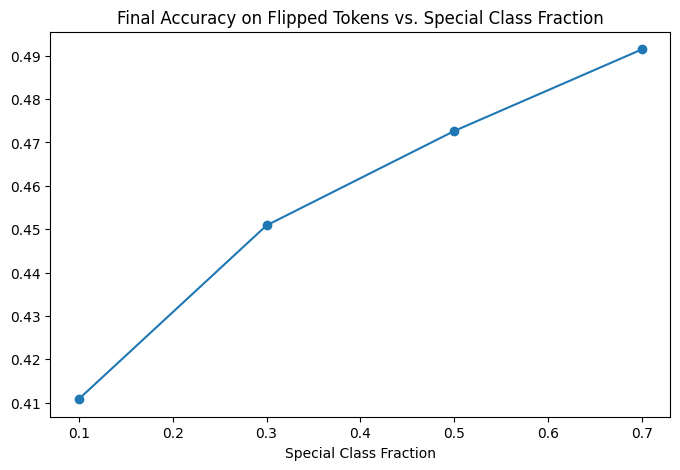

In [52]:
#plot acc on special flipped tokens 
import matplotlib.pyplot as plt
fractions = [r["fraction"] for r in fine_tune_results]
final_accs = [r["switched_acc_final"] for r in fine_tune_results]
plt.figure(figsize=(8, 5))
plt.plot(fractions, final_accs, marker='o')
plt.title("Final Accuracy on Flipped Tokens vs. Special Class Fraction")
plt.xlabel("Special Class Fraction")

Animal-task eval samples: 150
Non-animal eval samples: 150

Evaluating: pretrained -> SauravP97/tiny-stories-3M


Loading weights:   0%|          | 0/108 [00:00<?, ?it/s]

{'model': 'pretrained', 'animal_acc': 0.49341796804558735, 'animal_ppl': 10.903453826904297, 'animal_tokens': 27727, 'non_animal_acc': 0.5484825348348922, 'non_animal_ppl': 6.701906204223633, 'non_animal_tokens': 31434}

Evaluating: finetuned_0.1 -> ./finetune_runs/special_frac_0_1/final_model


Loading weights:   0%|          | 0/108 [00:00<?, ?it/s]

{'model': 'finetuned_0.1', 'animal_acc': 0.5174018105096115, 'animal_ppl': 8.40390682220459, 'animal_tokens': 27727, 'non_animal_acc': 0.5657886365082395, 'non_animal_ppl': 6.1629533767700195, 'non_animal_tokens': 31434}

Evaluating: finetuned_0.3 -> ./finetune_runs/special_frac_0_3/final_model


...

{'model': 'finetuned_0.3', 'animal_acc': 0.5197100299347207, 'animal_ppl': 8.228012084960938, 'animal_tokens': 27727, 'non_animal_acc': 0.5627664312527836, 'non_animal_ppl': 6.3249382972717285, 'non_animal_tokens': 31434}

Evaluating: finetuned_0.5 -> ./finetune_runs/special_frac_0_5/final_model


Loading weights:   0%|          | 0/108 [00:00<?, ?it/s]

{'model': 'finetuned_0.5', 'animal_acc': 0.5200346232913766, 'animal_ppl': 8.192161560058594, 'animal_tokens': 27727, 'non_animal_acc': 0.55821721702615, 'non_animal_ppl': 6.4272871017456055, 'non_animal_tokens': 31434}

Evaluating: finetuned_0.7 -> ./finetune_runs/special_frac_0_7/final_model


Loading weights:   0%|          | 0/108 [00:00<?, ?it/s]

{'model': 'finetuned_0.7', 'animal_acc': 0.5209362715043099, 'animal_ppl': 8.175003051757812, 'animal_tokens': 27727, 'non_animal_acc': 0.5532544378698225, 'non_animal_ppl': 6.540369987487793, 'non_animal_tokens': 31434}

=== Summary ===
    pretrained | animal acc=0.4934, ppl=10.90 | non-animal acc=0.5485, ppl=6.70
 finetuned_0.1 | animal acc=0.5174, ppl=8.40 | non-animal acc=0.5658, ppl=6.16
 finetuned_0.3 | animal acc=0.5197, ppl=8.23 | non-animal acc=0.5628, ppl=6.32
 finetuned_0.5 | animal acc=0.5200, ppl=8.19 | non-animal acc=0.5582, ppl=6.43
 finetuned_0.7 | animal acc=0.5209, ppl=8.18 | non-animal acc=0.5533, ppl=6.54


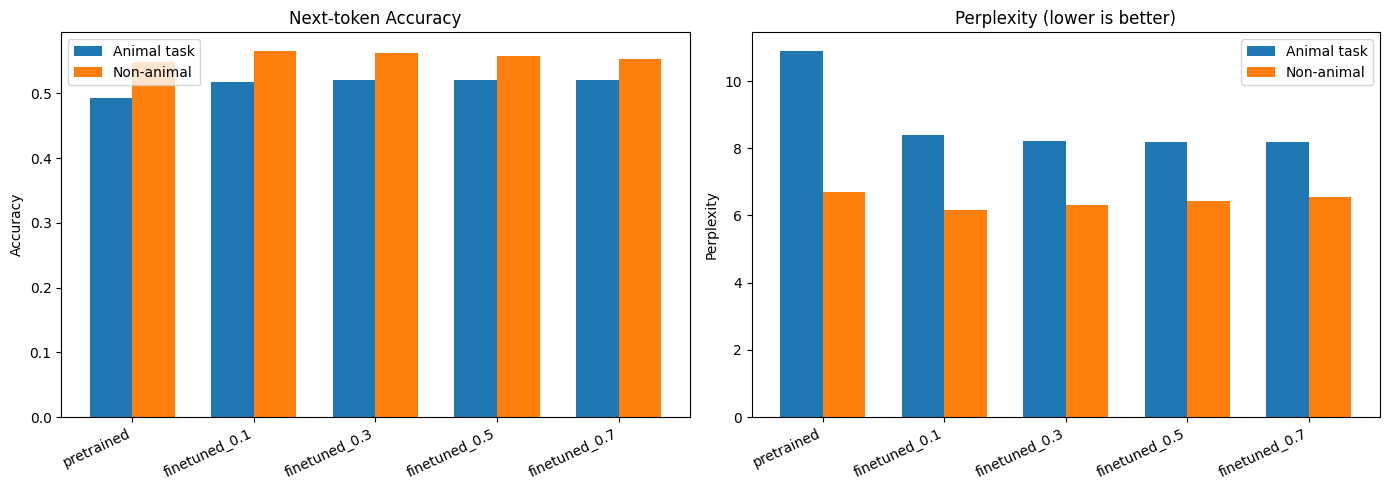

In [53]:
# Evaluate pretrained + fine-tuned models on animal-task vs non-animal subsets, then plot
import os
import math

try:
    import matplotlib.pyplot as plt
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "matplotlib"])
    import matplotlib.pyplot as plt

EVAL_PER_SPLIT = 150  # per task split, per model (increase for more stable metrics)

# Build evaluation pools from validation data
animal_eval = []
non_animal_eval = []
for ex in val_full:
    text = ex["text"]
    if len(animal_eval) < EVAL_PER_SPLIT and is_flippable_animal_story(text):
        animal_eval.append(flip_gender_pronouns(text))
    elif len(non_animal_eval) < EVAL_PER_SPLIT and (not is_animal_story(text)):
        non_animal_eval.append(text)

if len(animal_eval) == 0 or len(non_animal_eval) == 0:
    raise ValueError("Could not build eval splits for animal/non-animal tasks")

print(f"Animal-task eval samples: {len(animal_eval)}")
print(f"Non-animal eval samples: {len(non_animal_eval)}")

def eval_texts(model_obj, texts, max_len=MAX_LENGTH):
    correct = 0
    total = 0
    nll_sum = 0.0
    tok_count = 0

    for text in texts:
        enc = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=max_len,
            add_special_tokens=False,
        )
        ids = enc["input_ids"]
        if ids.shape[1] < 2:
            continue

        ids = ids.to(device)
        with torch.no_grad():
            out = model_obj(input_ids=ids)
            logits = out.logits[:, :-1, :]
            labels = ids[:, 1:]

            preds = torch.argmax(logits, dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.numel()

            log_probs = torch.log_softmax(logits, dim=-1)
            target_lp = log_probs.gather(-1, labels.unsqueeze(-1)).squeeze(-1)
            nll_sum += (-target_lp).sum().item()
            tok_count += labels.numel()

    acc = correct / total if total else float("nan")
    ppl = float(torch.exp(torch.tensor(nll_sum / tok_count))) if tok_count else float("nan")
    return acc, ppl, total

# Collect model paths: pretrained reference + fine-tuned runs
model_rows = [("pretrained", MODEL_ID)]
for frac in SPECIAL_CLASS_FRACTIONS:
    run_name = f"special_frac_{str(frac).replace('.', '_')}"
    path = os.path.join(OUTPUT_ROOT, run_name, "final_model")
    if os.path.exists(path):
        model_rows.append((f"finetuned_{frac}", path))

if len(model_rows) == 1:
    print("No fine-tuned checkpoints found under finetune_runs; only pretrained baseline will be evaluated.")

results = []
for label, path in model_rows:
    print(f"\nEvaluating: {label} -> {path}")
    m = load_causal_lm_compat(path, trust_remote_code=True).to(device)
    m.eval()

    a_acc, a_ppl, a_tok = eval_texts(m, animal_eval, max_len=MAX_LENGTH)
    n_acc, n_ppl, n_tok = eval_texts(m, non_animal_eval, max_len=MAX_LENGTH)

    row = {
        "model": label,
        "animal_acc": a_acc,
        "animal_ppl": a_ppl,
        "animal_tokens": a_tok,
        "non_animal_acc": n_acc,
        "non_animal_ppl": n_ppl,
        "non_animal_tokens": n_tok,
    }
    results.append(row)
    print(row)

    del m
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Print compact table
print("\n=== Summary ===")
for row in results:
    print(
        f"{row['model']:>14} | "
        f"animal acc={row['animal_acc']:.4f}, ppl={row['animal_ppl']:.2f} | "
        f"non-animal acc={row['non_animal_acc']:.4f}, ppl={row['non_animal_ppl']:.2f}"
    )

# Plot: accuracy and perplexity by task
labels = [r["model"] for r in results]
x = list(range(len(labels)))
bar_w = 0.35

animal_accs = [r["animal_acc"] for r in results]
non_animal_accs = [r["non_animal_acc"] for r in results]
animal_ppls = [r["animal_ppl"] for r in results]
non_animal_ppls = [r["non_animal_ppl"] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar([i - bar_w / 2 for i in x], animal_accs, width=bar_w, label="Animal task")
axes[0].bar([i + bar_w / 2 for i in x], non_animal_accs, width=bar_w, label="Non-animal")
axes[0].set_title("Next-token Accuracy")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=25, ha="right")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].bar([i - bar_w / 2 for i in x], animal_ppls, width=bar_w, label="Animal task")
axes[1].bar([i + bar_w / 2 for i in x], non_animal_ppls, width=bar_w, label="Non-animal")
axes[1].set_title("Perplexity (lower is better)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=25, ha="right")
axes[1].set_ylabel("Perplexity")
axes[1].legend()

plt.tight_layout()
plt.show()

In [54]:
# Generate stories from each fine-tuned model for quick comparison
comparison_prompts = [
    "Once upon a time",
    "In the forest",
    'Once upon a time, there was a playful bunny named Benny'
]

gen_kwargs_ft = dict(
    max_length=140,
    do_sample=True,
    temperature=0.8,
    top_k=50,
    pad_token_id=tokenizer.eos_token_id,
    use_cache=True,
)

for fraction in SPECIAL_CLASS_FRACTIONS:
    if fraction not in run_dirs:
        continue

    print(f"\n######## Fraction {fraction} ########")
    model_path = run_dirs[fraction]
    model_gen = load_causal_lm_compat(model_path, trust_remote_code=True).to(device)
    model_gen.eval()

    for j, prompt in enumerate(comparison_prompts, start=1):
        enc = tokenizer(prompt, return_tensors="pt")
        if enc["input_ids"].shape[1] == 0:
            print(f"Prompt {j}: skipped due to empty tokenization")
            continue

        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            out_ids = model_gen.generate(**enc, **gen_kwargs_ft)
        text = tokenizer.decode(out_ids[0], skip_special_tokens=True)
        print(f"\n--- Fraction {fraction} | Story {j} ---")
        print(text)

    del model_gen
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


######## Fraction 0.1 ########


Loading weights:   0%|          | 0/108 [00:00<?, ?it/s]


--- Fraction 0.1 | Story 1 ---
Once upon a time, there was a little boy named Timmy. Timmy liked to play with his toy cars on the floor. One day, Timmy's mom gave him a big bowl of water to drink. Timmy felt sad because he didn't want to eat some. 

After playing, Timmy's mommy put a cup on the cup and said, "I will make a cup for you." Timmy was happy that his mom was done because he had a snack. Timmy felt happy and proud.

From that day on, Timmy made sure to take a bath in the cup without asking for breakfast. His mom always made him a new cup of

--- Fraction 0.1 | Story 2 ---
In the forest, there was a little girl named Lucy. She was very impatient because she wanted to have some fun. She asked her mom if she could help. Her mom said yes, so Lucy and her mom were very patient.

They went to the market and got some things to make the people who were very nice. Lucy and her mom used to help the people in the market.

Next, Lucy took a ruler of the market and opened the market. The

Loading weights:   0%|          | 0/108 [00:00<?, ?it/s]


--- Fraction 0.3 | Story 1 ---
Once upon a time, there was a girl named Lucy. She was very hungry and wanted to help her mom. She had to help her mom in the kitchen, but she was very sad.

One day, her mom said, "Lucy, you need to help you. You can be happy and help you."

Lucy was very excited. She wanted to help her mom. She saw her mom's neighbor, Tom, and her mom. "Don't worry, Lucy. This is the tray. It's not a gift."

Lucy's mom replied, "I know, Tim. Let's help you to get the tray." She helped Lucy carefully cut

--- Fraction 0.3 | Story 2 ---
In the forest, a boy named Tim and his dog named Tim. Tim wanted to play with Tim's dog, but Tim was shy. Tim had a toy, a big dog. Tim went to Tim and gave him a treat.

Tim was brave and said, "I can teach you a lesson, Tim. I will always feel brave." Tim wagged hers tail and said, "I hope I will have you a nice nap." They all laughed and played together.

As they played, a boy came over and asked, "Can I play with you?" Tim said, "Sure

Loading weights:   0%|          | 0/108 [00:00<?, ?it/s]


--- Fraction 0.5 | Story 1 ---
Once upon a time, there was a little girl named Lily. She loved to play with her dolls in her room. One day, she put a big box under a table and started to draw on her favorite doll. She drew a picture of the picture of a princess named Lily. 

"Hello, Lily! You are my friend!" said Lily. "I love to draw with the pictures!" Lily smiled and smiled. "You are so pretty, Lily!" said Lily. "Thank you, Lily. I am very happy today." 

Suddenly, Lily saw Lily's doll on the floor. "Don't worry," said Lily. "I will show you your doll Lily

--- Fraction 0.5 | Story 2 ---
In the forest, there lived a bird with a kind owner. The bird loved to climb the tree and make sure it was safe. One day, the bird noticed a nest in the sky. It was not a place. She decided to pick it up and carry it around.

Once she picked it up, the bird was so happy. It made a cozy nest for her friend. The owner was so happy and grateful to the dog. After a few days, the bird went back to its n

Loading weights:   0%|          | 0/108 [00:00<?, ?it/s]


--- Fraction 0.7 | Story 1 ---
Once upon a time, there was a little girl named Lily. He had a big dog named Spot. One day, Lily and Spot went for a walk in a pond. But when he got there, he saw a leak! It was a leak!

"Ouch!" said Spot. "Don't worry, I will help you."

Lily was sad and tried to dry the leak with hers hands. But Spot didn't listen.

"But I don't know, I will protect you," said Lily. "Don't worry, I'll help you. I will help you."

From that day on, Lily and Spot played together every day and had

--- Fraction 0.7 | Story 2 ---
In the forest, there was a monkey named Tom. Tom was an enormous monkey. She loved bananas and loved her very much. Every day she would go to the zoo and play with hers friends.

One day, Tom saw a lion. The lion had an idea. She asked Tom if she could race. Tom said yes and let the lion get the lion. They took turns throwing the monkey and laughing. They were both very happy and started to play with the animals.

Suddenly, Tom's friends heard and

In [55]:
# Quick composition/step check (no training)
effective_batch_size = TRAIN_BATCH_SIZE * GRAD_ACCUM_STEPS
for f in SPECIAL_CLASS_FRACTIONS:
    ds_tmp, stats_tmp = build_special_train_dataset(f, seed=42)
    steps_tmp = math.ceil(stats_tmp["dataset_size"] / effective_batch_size)
    print(
        f"fraction={f:.2f} | special={stats_tmp['special_count']} | non_animal={stats_tmp['non_animal_count']} | "
        f"actual_fraction={stats_tmp['actual_fraction']:.4f} | steps={steps_tmp}"
    )

fraction=0.10 | special=10000 | non_animal=90000 | actual_fraction=0.1000 | steps=6250
fraction=0.30 | special=10000 | non_animal=23334 | actual_fraction=0.3000 | steps=2084
fraction=0.50 | special=10000 | non_animal=10000 | actual_fraction=0.5000 | steps=1250
fraction=0.70 | special=10000 | non_animal=4286 | actual_fraction=0.7000 | steps=893


Animal pronoun-flip eval samples: 200


Tokenizing continuation non-animal data:   0%|          | 0/4000 [00:00<?, ? examples/s]


=== Continue training fraction 0.1 ===


Loading weights:   0%|          | 0/108 [00:00<?, ?it/s]

Before: animal-flip acc=0.5029, ppl=9.19, tokens=37128


...

Before: animal-flip acc=0.5070, ppl=8.95, tokens=37128


Step,Training Loss,Validation Loss
30,2.186580,2.152944
60,2.144994,2.149115
90,2.145998,2.147531
120,2.147732,2.146870


[switched-metric] continue_frac_0.7 step=30 acc=0.4595 loss=2.1706 ppl=8.76
[switched-metric] continue_frac_0.7 step=60 acc=0.4520 loss=2.2194 ppl=9.20
[switched-metric] continue_frac_0.7 step=90 acc=0.4420 loss=2.2673 ppl=9.65
[switched-metric] continue_frac_0.7 step=120 acc=0.4366 loss=2.2868 ppl=9.84


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

After : animal-flip acc=0.5040, ppl=9.13, tokens=37128
{'fraction': 0.7, 'before_acc': 0.5070297349709114, 'after_acc': 0.5039862098685628, 'delta_acc': -0.003043525102348621, 'before_ppl': 8.945276260375977, 'after_ppl': 9.133566856384277, 'delta_ppl': 0.18829059600830078, 'continued_model_path': './finetune_runs/special_frac_0_7/continued_non_animal'}

=== Continuation summary (animal pronoun-flip set) ===
frac=0.1 | acc 0.5029->0.5008 (Δ-0.0021) | ppl 9.19->9.30 (Δ+0.11)
frac=0.3 | acc 0.5059->0.5036 (Δ-0.0023) | ppl 9.00->9.14 (Δ+0.14)
frac=0.5 | acc 0.5064->0.5045 (Δ-0.0019) | ppl 8.96->9.12 (Δ+0.17)
frac=0.7 | acc 0.5070->0.5040 (Δ-0.0030) | ppl 8.95->9.13 (Δ+0.19)


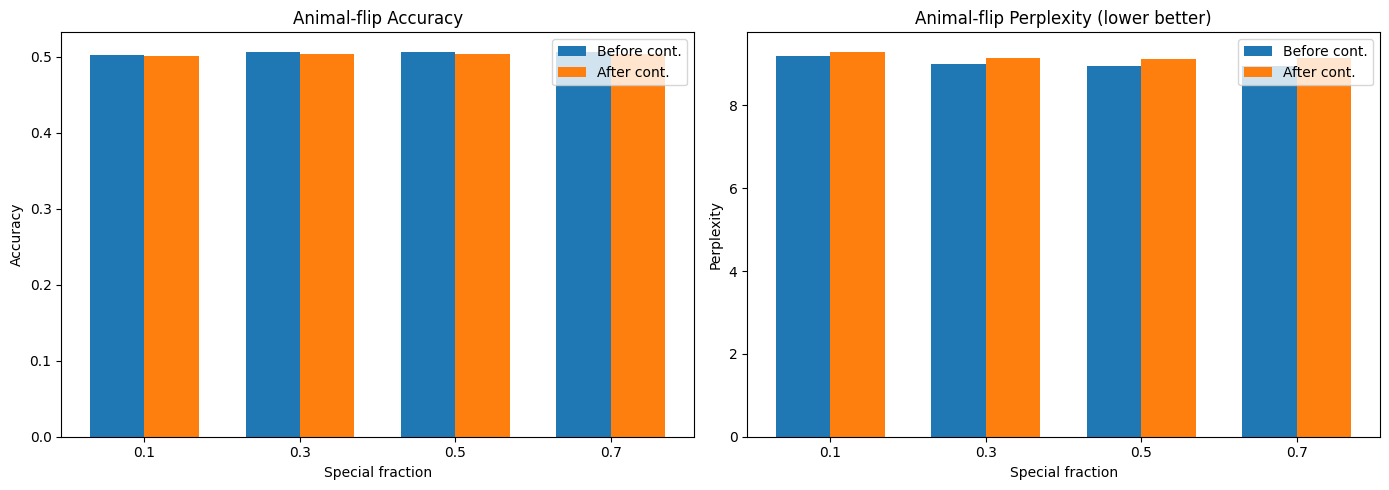

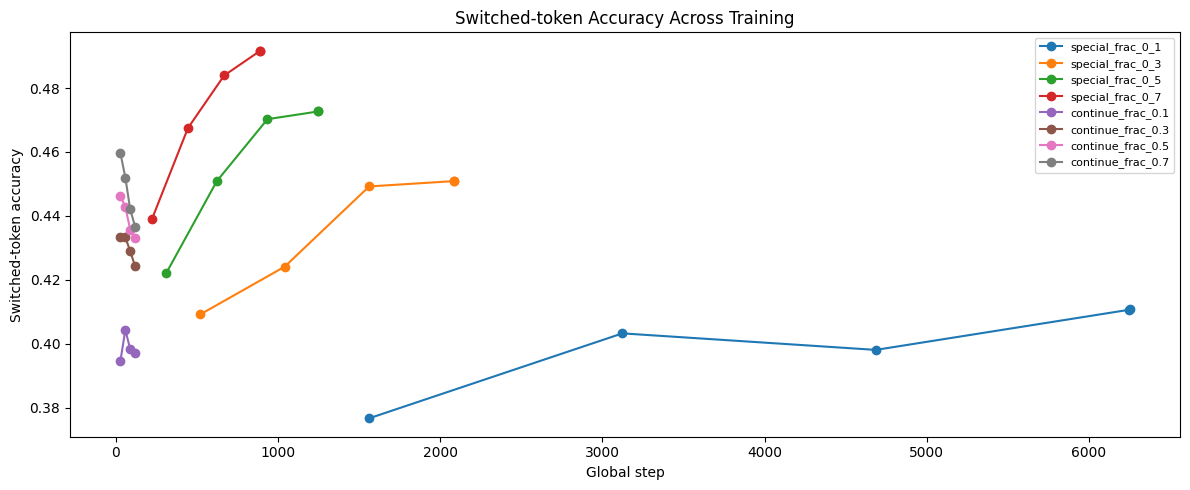

In [56]:
# Continue training each fine-tuned model on non-animal data only,
# and track switched-token accuracy across continuation steps.
import os
import math

try:
    import matplotlib.pyplot as plt
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "matplotlib"])
    import matplotlib.pyplot as plt

CONTINUE_NON_ANIMAL_SAMPLES = 4000
CONTINUE_STEPS = 120
CONTINUE_LR = 5e-5
CONTINUE_WARMUP_STEPS = 20
CONTINUE_EVAL_STEPS = 30
ANIMAL_EVAL_SAMPLES = 200

# Build/refresh animal pronoun-flip eval set
animal_flip_eval = []
for ex in val_full:
    text = ex["text"]
    if is_flippable_animal_story(text):
        animal_flip_eval.append(flip_gender_pronouns(text))
    if len(animal_flip_eval) >= ANIMAL_EVAL_SAMPLES:
        break

if len(animal_flip_eval) == 0:
    raise ValueError("No animal pronoun-flip eval samples found")

print("Animal pronoun-flip eval samples:", len(animal_flip_eval))

# Build continuation dataset from non-animal-only pretrain pool
if len(non_animal_texts) < CONTINUE_NON_ANIMAL_SAMPLES:
    raise ValueError(
        f"Need {CONTINUE_NON_ANIMAL_SAMPLES} non-animal samples, but only {len(non_animal_texts)} available"
    )

rng = np.random.default_rng(123)
cont_idx = rng.choice(len(non_animal_texts), size=CONTINUE_NON_ANIMAL_SAMPLES, replace=False)
cont_texts = [non_animal_texts[i] for i in cont_idx]
cont_ds = Dataset.from_dict({"text": cont_texts})
cont_tok = cont_ds.map(
    tokenize_for_lm,
    batched=True,
    remove_columns=cont_ds.column_names,
    desc="Tokenizing continuation non-animal data",
)

def eval_animal_flip(model_obj, texts, max_len=MAX_LENGTH):
    correct = 0
    total = 0
    nll_sum = 0.0
    tok_count = 0

    for text in texts:
        enc = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=max_len,
            add_special_tokens=False,
        )
        ids = enc["input_ids"]
        if ids.shape[1] < 2:
            continue

        ids = ids.to(device)
        with torch.no_grad():
            out = model_obj(input_ids=ids)
            logits = out.logits[:, :-1, :]
            labels = ids[:, 1:]

            preds = torch.argmax(logits, dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.numel()

            log_probs = torch.log_softmax(logits, dim=-1)
            target_lp = log_probs.gather(-1, labels.unsqueeze(-1)).squeeze(-1)
            nll_sum += (-target_lp).sum().item()
            tok_count += labels.numel()

    acc = correct / total if total else float("nan")
    ppl = float(torch.exp(torch.tensor(nll_sum / tok_count))) if tok_count else float("nan")
    return acc, ppl, total

# Which models to continue
continue_rows = []
for frac in SPECIAL_CLASS_FRACTIONS:
    run_name = f"special_frac_{str(frac).replace('.', '_')}"
    base_path = os.path.join(OUTPUT_ROOT, run_name, "final_model")
    if os.path.exists(base_path):
        continue_rows.append((frac, base_path, os.path.join(OUTPUT_ROOT, run_name, "continued_non_animal")))

if len(continue_rows) == 0:
    raise ValueError("No fine-tuned model checkpoints found to continue training")

continuation_results = []
for frac, base_path, out_path in continue_rows:
    print(f"\n=== Continue training fraction {frac} ===")

    model_cont = load_causal_lm_compat(base_path, trust_remote_code=True).to(device)
    model_cont.config.pad_token_id = tokenizer.pad_token_id
    model_cont.eval()

    before_acc, before_ppl, before_tok = eval_animal_flip(model_cont, animal_flip_eval, max_len=MAX_LENGTH)
    print(f"Before: animal-flip acc={before_acc:.4f}, ppl={before_ppl:.2f}, tokens={before_tok}")

    args_candidate = {
        "output_dir": out_path,
        "num_train_epochs": 1,
        "max_steps": CONTINUE_STEPS,
        "learning_rate": CONTINUE_LR,
        "per_device_train_batch_size": TRAIN_BATCH_SIZE,
        "per_device_eval_batch_size": EVAL_BATCH_SIZE,
        "gradient_accumulation_steps": GRAD_ACCUM_STEPS,
        "weight_decay": WEIGHT_DECAY,
        "warmup_steps": CONTINUE_WARMUP_STEPS,
        "logging_steps": max(10, CONTINUE_STEPS // 6),
        "save_strategy": "no",
        "report_to": [],
        "fp16": torch.cuda.is_available(),
        "dataloader_num_workers": 2,
    }

    import inspect
    sig = inspect.signature(TrainingArguments.__init__).parameters
    if "overwrite_output_dir" in sig:
        args_candidate["overwrite_output_dir"] = True
    if "eval_strategy" in sig:
        args_candidate["eval_strategy"] = "steps"
    elif "evaluation_strategy" in sig:
        args_candidate["evaluation_strategy"] = "steps"
    if "eval_steps" in sig:
        args_candidate["eval_steps"] = CONTINUE_EVAL_STEPS

    safe_args = {k: v for k, v in args_candidate.items() if k in sig}
    cont_args = TrainingArguments(**safe_args)

    collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
    trainer_kwargs = {
        "model": model_cont,
        "args": cont_args,
        "train_dataset": cont_tok,
        "eval_dataset": val_tok,
        "data_collator": collator,
    }
    trainer_sig = inspect.signature(Trainer.__init__).parameters
    if "tokenizer" in trainer_sig:
        trainer_kwargs["tokenizer"] = tokenizer

    cont_run_name = f"continue_frac_{frac}"
    cont_trainer = Trainer(**trainer_kwargs)
    cont_trainer.add_callback(SwitchedMetricCallback(cont_run_name, switched_history, track_switch_eval))
    cont_trainer.train()

    os.makedirs(out_path, exist_ok=True)
    cont_trainer.save_model(out_path)
    tokenizer.save_pretrained(out_path)

    model_cont.eval()
    after_acc, after_ppl, after_tok = eval_animal_flip(model_cont, animal_flip_eval, max_len=MAX_LENGTH)
    print(f"After : animal-flip acc={after_acc:.4f}, ppl={after_ppl:.2f}, tokens={after_tok}")

    row = {
        "fraction": frac,
        "before_acc": before_acc,
        "after_acc": after_acc,
        "delta_acc": after_acc - before_acc,
        "before_ppl": before_ppl,
        "after_ppl": after_ppl,
        "delta_ppl": after_ppl - before_ppl,
        "continued_model_path": out_path,
    }
    continuation_results.append(row)
    print(row)

    del cont_trainer
    del model_cont
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\n=== Continuation summary (animal pronoun-flip set) ===")
for row in continuation_results:
    print(
        f"frac={row['fraction']:.1f} | "
        f"acc {row['before_acc']:.4f}->{row['after_acc']:.4f} (Δ{row['delta_acc']:+.4f}) | "
        f"ppl {row['before_ppl']:.2f}->{row['after_ppl']:.2f} (Δ{row['delta_ppl']:+.2f})"
    )

# Plot before/after continuation endpoint
fractions = [r["fraction"] for r in continuation_results]
x = np.arange(len(fractions))
bar_w = 0.35

before_accs = [r["before_acc"] for r in continuation_results]
after_accs = [r["after_acc"] for r in continuation_results]
before_ppls = [r["before_ppl"] for r in continuation_results]
after_ppls = [r["after_ppl"] for r in continuation_results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(x - bar_w / 2, before_accs, width=bar_w, label="Before cont.")
axes[0].bar(x + bar_w / 2, after_accs, width=bar_w, label="After cont.")
axes[0].set_title("Animal-flip Accuracy")
axes[0].set_xticks(x)
axes[0].set_xticklabels([str(f) for f in fractions])
axes[0].set_xlabel("Special fraction")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].bar(x - bar_w / 2, before_ppls, width=bar_w, label="Before cont.")
axes[1].bar(x + bar_w / 2, after_ppls, width=bar_w, label="After cont.")
axes[1].set_title("Animal-flip Perplexity (lower better)")
axes[1].set_xticks(x)
axes[1].set_xticklabels([str(f) for f in fractions])
axes[1].set_xlabel("Special fraction")
axes[1].set_ylabel("Perplexity")
axes[1].legend()

plt.tight_layout()
plt.show()

# Plot switched-token accuracy trajectories across training for all runs
plt.figure(figsize=(12, 5))
for run_name, hist in switched_history.items():
    if len(hist) == 0:
        continue
    steps = [h["step"] for h in hist]
    vals = [h["switched_acc"] for h in hist]
    plt.plot(steps, vals, marker="o", label=run_name)
plt.title("Switched-token Accuracy Across Training")
plt.xlabel("Global step")
plt.ylabel("Switched-token accuracy")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

Slow tokenizer: GPT2Tokenizer | Fast tokenizer: GPT2Tokenizer
Vocab sizes: 50257 50257
Switched-span eval samples: 120
Evaluating switched-token loss: pretrained


Loading weights:   0%|          | 0/108 [00:00<?, ?it/s]

{'switched_tokens': 1195, 'switched_acc': 0.22845188284518828, 'switched_loss': 4.740310060535266, 'switched_ppl': 114.4697036743164, 'model': 'pretrained'}
Evaluating switched-token loss: ft_0.1


Loading weights:   0%|          | 0/108 [00:00<?, ?it/s]

{'switched_tokens': 1195, 'switched_acc': 0.40753138075313805, 'switched_loss': 2.29613288330639, 'switched_ppl': 9.935685157775879, 'model': 'ft_0.1'}
Evaluating switched-token loss: ft_0.1_cont


...

{'switched_tokens': 1195, 'switched_acc': 0.4476987447698745, 'switched_loss': 2.263544687391824, 'switched_ppl': 9.617119789123535, 'model': 'ft_0.5_cont'}
Evaluating switched-token loss: ft_0.7


Loading weights:   0%|          | 0/108 [00:00<?, ?it/s]

{'switched_tokens': 1195, 'switched_acc': 0.501255230125523, 'switched_loss': 1.9863107640748243, 'switched_ppl': 7.2885942459106445, 'model': 'ft_0.7'}
Evaluating switched-token loss: ft_0.7_cont


Loading weights:   0%|          | 0/108 [00:00<?, ?it/s]

{'switched_tokens': 1195, 'switched_acc': 0.44184100418410044, 'switched_loss': 2.2524770280416417, 'switched_ppl': 9.511265754699707, 'model': 'ft_0.7_cont'}

=== Switched-token summary ===
    pretrained | tokens=1195 | acc=0.2285 | loss=4.7403 | ppl=114.47
        ft_0.1 | tokens=1195 | acc=0.4075 | loss=2.2961 | ppl=9.94
   ft_0.1_cont | tokens=1195 | acc=0.4025 | loss=2.3867 | ppl=10.88
        ft_0.3 | tokens=1195 | acc=0.4603 | loss=2.1188 | ppl=8.32
   ft_0.3_cont | tokens=1195 | acc=0.4285 | loss=2.2726 | ppl=9.70
        ft_0.5 | tokens=1195 | acc=0.4812 | loss=2.0504 | ppl=7.77
   ft_0.5_cont | tokens=1195 | acc=0.4477 | loss=2.2635 | ppl=9.62
        ft_0.7 | tokens=1195 | acc=0.5013 | loss=1.9863 | ppl=7.29
   ft_0.7_cont | tokens=1195 | acc=0.4418 | loss=2.2525 | ppl=9.51


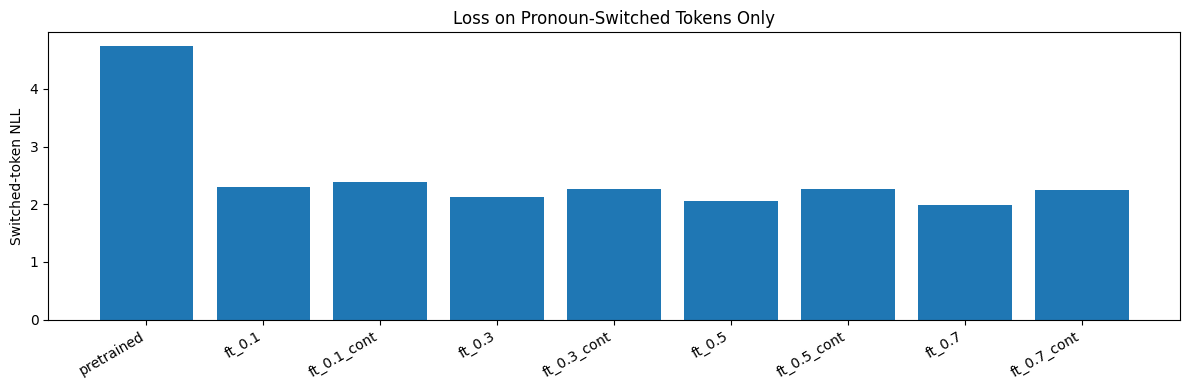

In [57]:
# Focused metric: evaluate only pronoun-switched token positions
import os
import re

EVAL_SWITCHED_SAMPLES = 120

# Use fast tokenizer for char-offset alignment of switched spans
fast_tok = AutoTokenizer.from_pretrained(TOKENIZER_ID_FALLBACK, use_fast=True)
if fast_tok.pad_token is None:
    fast_tok.pad_token = fast_tok.eos_token

print("Slow tokenizer:", tokenizer.__class__.__name__, "| Fast tokenizer:", fast_tok.__class__.__name__)
print("Vocab sizes:", tokenizer.vocab_size, fast_tok.vocab_size)

# Build flipped samples + switched character spans
def flip_gender_with_spans(text: str):
    out_parts = []
    spans = []
    cursor = 0
    out_len = 0

    for m in _GENDER_PATTERN.finditer(text):
        src = m.group(0)
        dst = _preserve_case(src, _GENDER_FLIP[src.lower()])

        prefix = text[cursor:m.start()]
        out_parts.append(prefix)
        out_len += len(prefix)

        out_parts.append(dst)
        spans.append((out_len, out_len + len(dst)))
        out_len += len(dst)

        cursor = m.end()

    tail = text[cursor:]
    out_parts.append(tail)
    flipped = "".join(out_parts)
    return flipped, spans

switch_eval = []
for ex in val_full:
    text = ex["text"]
    if is_flippable_animal_story(text):
        flipped, spans = flip_gender_with_spans(text)
        if len(spans) > 0:
            switch_eval.append((flipped, spans))
    if len(switch_eval) >= EVAL_SWITCHED_SAMPLES:
        break

if len(switch_eval) == 0:
    raise ValueError("No switched-span eval samples available")

print("Switched-span eval samples:", len(switch_eval))

def overlaps(span_a, span_b):
    return span_a[0] < span_b[1] and span_b[0] < span_a[1]

def eval_switched_positions(model_obj, eval_pairs, max_len=MAX_LENGTH):
    switched_nll = 0.0
    switched_tokens = 0
    switched_correct = 0

    for flipped_text, switched_spans in eval_pairs:
        enc = fast_tok(
            flipped_text,
            return_tensors="pt",
            truncation=True,
            max_length=max_len,
            add_special_tokens=False,
            return_offsets_mapping=True,
        )

        ids = enc["input_ids"]
        offsets = enc["offset_mapping"][0]

        if ids.shape[1] < 2:
            continue

        ids = ids.to(device)
        with torch.no_grad():
            out = model_obj(input_ids=ids)
            logits = out.logits[:, :-1, :]
            labels = ids[:, 1:]

            log_probs = torch.log_softmax(logits, dim=-1)
            target_lp = log_probs.gather(-1, labels.unsqueeze(-1)).squeeze(-1)
            preds = torch.argmax(logits, dim=-1)

            # label index j corresponds to token index j+1 in original input
            for j in range(labels.shape[1]):
                token_span = tuple(int(x) for x in offsets[j + 1].tolist())
                if token_span[0] == token_span[1]:
                    continue

                if any(overlaps(token_span, sw) for sw in switched_spans):
                    switched_tokens += 1
                    switched_nll += (-target_lp[0, j]).item()
                    switched_correct += int((preds[0, j] == labels[0, j]).item())

    switched_acc = switched_correct / switched_tokens if switched_tokens else float("nan")
    switched_ppl = float(torch.exp(torch.tensor(switched_nll / switched_tokens))) if switched_tokens else float("nan")
    switched_loss = switched_nll / switched_tokens if switched_tokens else float("nan")

    return {
        "switched_tokens": switched_tokens,
        "switched_acc": switched_acc,
        "switched_loss": switched_loss,
        "switched_ppl": switched_ppl,
    }

# Evaluate pretrained + finetuned + continued models
rows = [("pretrained", MODEL_ID)]
for frac in SPECIAL_CLASS_FRACTIONS:
    run_name = f"special_frac_{str(frac).replace('.', '_')}"
    final_path = os.path.join(OUTPUT_ROOT, run_name, "final_model")
    cont_path = os.path.join(OUTPUT_ROOT, run_name, "continued_non_animal")
    if os.path.exists(final_path):
        rows.append((f"ft_{frac}", final_path))
    if os.path.exists(cont_path):
        rows.append((f"ft_{frac}_cont", cont_path))

switched_results = []
for name, path in rows:
    print(f"Evaluating switched-token loss: {name}")
    m = load_causal_lm_compat(path, trust_remote_code=True).to(device)
    m.eval()
    metrics = eval_switched_positions(m, switch_eval, max_len=MAX_LENGTH)
    metrics["model"] = name
    switched_results.append(metrics)
    print(metrics)

    del m
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\n=== Switched-token summary ===")
for r in switched_results:
    print(
        f"{r['model']:>14} | tokens={r['switched_tokens']} | "
        f"acc={r['switched_acc']:.4f} | loss={r['switched_loss']:.4f} | ppl={r['switched_ppl']:.2f}"
    )

# Plot switched-token loss (lower better)
labels_sw = [r["model"] for r in switched_results]
losses_sw = [r["switched_loss"] for r in switched_results]

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.bar(range(len(labels_sw)), losses_sw)
plt.xticks(range(len(labels_sw)), labels_sw, rotation=30, ha="right")
plt.ylabel("Switched-token NLL")
plt.title("Loss on Pronoun-Switched Tokens Only")
plt.tight_layout()
plt.show()

In [58]:
switched_accs = [r["switched_acc"] for r in switched_results]
models = [r["model"] for r in switched_results]

/tmp/ipykernel_7434/1060473755.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels([f"{f:.2f}" for f in fractions])


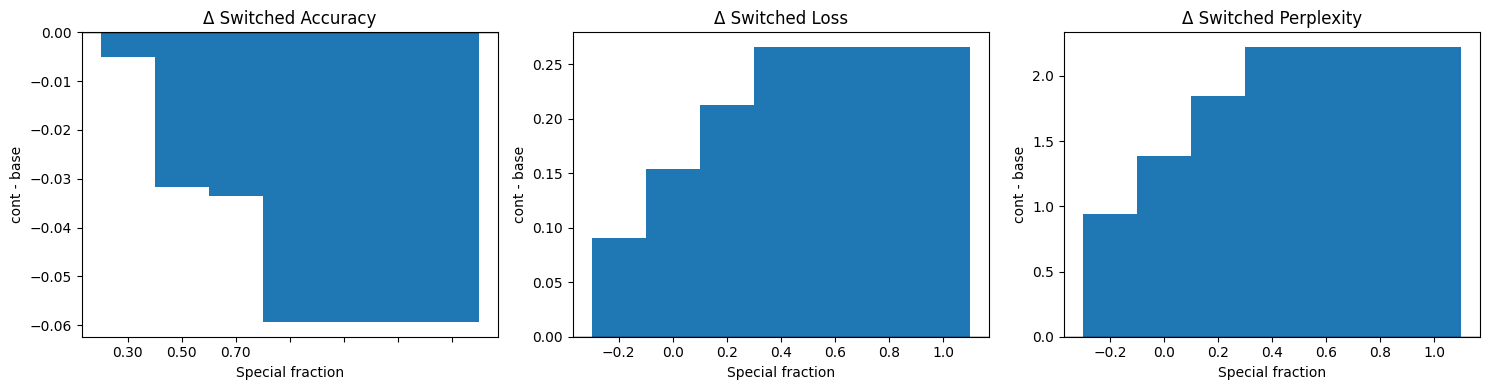

frac=0.1 | Δacc=-0.0050 | Δloss=+0.0905 | Δppl=+0.9417
frac=0.3 | Δacc=-0.0318 | Δloss=+0.1538 | Δppl=+1.3831
frac=0.5 | Δacc=-0.0335 | Δloss=+0.2132 | Δppl=+1.8464
frac=0.7 | Δacc=-0.0594 | Δloss=+0.2662 | Δppl=+2.2227


In [61]:
# Plot deltas: continued model - base fine-tuned model (from switched_results)
delta_rows = []

sr_map = {row["model"]: row for row in switched_results}

for frac in SPECIAL_CLASS_FRACTIONS:
    base_key = f"ft_{frac}"
    cont_key = f"ft_{frac}_cont"
    if base_key in sr_map and cont_key in sr_map:
        base = sr_map[base_key]
        cont = sr_map[cont_key]
        delta_rows.append({
            "fraction": frac,
            "delta_acc": cont["switched_acc"] - base["switched_acc"],
            "delta_loss": cont["switched_loss"] - base["switched_loss"],
            "delta_ppl": cont["switched_ppl"] - base["switched_ppl"],
        })

if not delta_rows:
    print("No matched (ft_x, ft_x_cont) pairs found in switched_results.")
else:
    fractions = [r["fraction"] for r in delta_rows]
    d_acc = [r["delta_acc"] for r in delta_rows]
    d_loss = [r["delta_loss"] for r in delta_rows]
    d_ppl = [r["delta_ppl"] for r in delta_rows]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].bar(fractions, d_acc)
    axes[0].axhline(0, color="black", linewidth=1)
    axes[0].set_title("Δ Switched Accuracy")
    axes[0].set_xlabel("Special fraction")
    axes[0].set_ylabel("cont - base")
    axes[0].set_xticklabels([f"{f:.2f}" for f in fractions])

    axes[1].bar(fractions, d_loss)
    axes[1].axhline(0, color="black", linewidth=1)
    axes[1].set_title("Δ Switched Loss")
    axes[1].set_xlabel("Special fraction")
    axes[1].set_ylabel("cont - base")

    axes[2].bar(fractions, d_ppl)
    axes[2].axhline(0, color="black", linewidth=1)
    axes[2].set_title("Δ Switched Perplexity")
    axes[2].set_xlabel("Special fraction")
    axes[2].set_ylabel("cont - base")

    plt.tight_layout()
    plt.show()

    for r in delta_rows:
        print(
            f"frac={r['fraction']:.1f} | "
            f"Δacc={r['delta_acc']:+.4f} | "
            f"Δloss={r['delta_loss']:+.4f} | "
            f"Δppl={r['delta_ppl']:+.4f}"
        )

Trying model: Qwen/Qwen2.5-1.5B-Instruct


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loaded model: Qwen/Qwen2.5-1.5B-Instruct
Collected instruct texts: 96
Collected normal texts: 192

=== Instruct prompt previews ===
[1] <|im_start|>system You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|> <|im_start|>user Give three tips for staying healthy.<|im_end|> <|im_start|>assistant 1. Eat a balanced and nutritious diet: Make sure your me
----------------------------------------------------------------------------------------------------
[2] <|im_start|>system You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|> <|im_start|>user What are the three primary colors?<|im_end|> <|im_start|>assistant The three primary colors are red, blue, and yellow. These 
----------------------------------------------------------------------------------------------------

=== Normal prompt previews ===
[1] Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valky

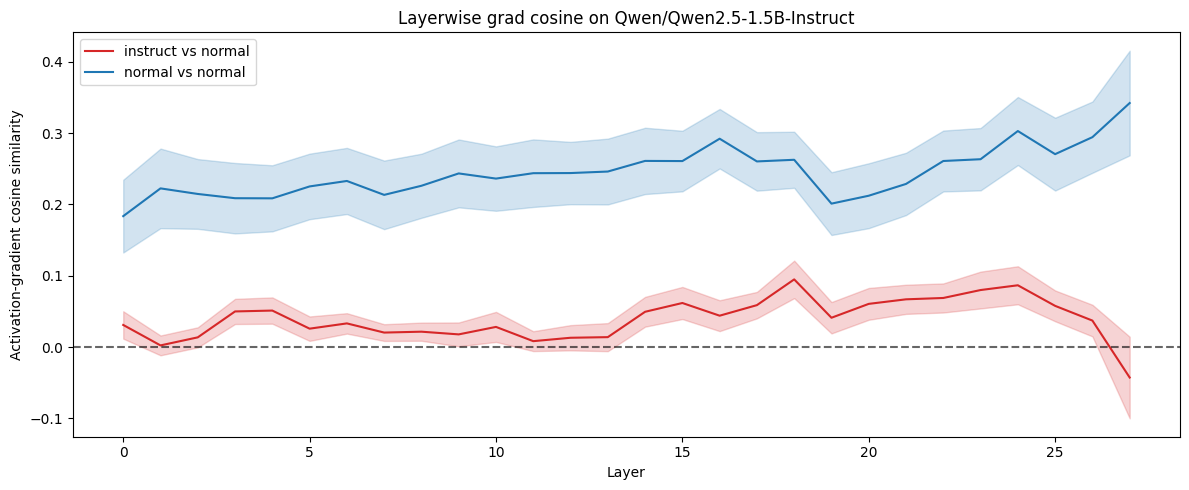

Most negative instruct-vs-normal layers:
layer=27 cross_mean=-0.0427 cross_std=0.0572 normal_mean=0.3420
layer=01 cross_mean=0.0024 cross_std=0.0139 normal_mean=0.2224
layer=11 cross_mean=0.0083 cross_std=0.0139 normal_mean=0.2437
layer=12 cross_mean=0.0131 cross_std=0.0177 normal_mean=0.2439
layer=02 cross_mean=0.0137 cross_std=0.0141 normal_mean=0.2146
layer=13 cross_mean=0.0139 cross_std=0.0197 normal_mean=0.2460
layer=09 cross_mean=0.0178 cross_std=0.0167 normal_mean=0.2434
layer=07 cross_mean=0.0203 cross_std=0.0117 normal_mean=0.2133
layer=08 cross_mean=0.0216 cross_std=0.0127 normal_mean=0.2261
layer=05 cross_mean=0.0258 cross_std=0.0171 normal_mean=0.2252


In [8]:
# Mid-size model test: layerwise gradient cosine on instruct vs normal prompts
import os
import sys
import subprocess
import importlib
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# Use shared memory for caching because the main filesystem is effectively full
HF_TMP_CACHE = "/dev/shm/hf_small_models_cache"
os.environ["HF_HOME"] = HF_TMP_CACHE
os.environ["TRANSFORMERS_CACHE"] = HF_TMP_CACHE
os.environ["HF_DATASETS_CACHE"] = os.path.join(HF_TMP_CACHE, "datasets")
os.makedirs(HF_TMP_CACHE, exist_ok=True)
os.makedirs(os.environ["HF_DATASETS_CACHE"], exist_ok=True)

# Optional dependency for practical 1-3B loading on one GPU
if torch.cuda.is_available():
    try:
        importlib.import_module("bitsandbytes")
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "bitsandbytes"])

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Prefer open instruct models in the 1-3B range
MODEL_CANDIDATES = [
    "Qwen/Qwen2.5-1.5B-Instruct",
    "HuggingFaceTB/SmolLM2-1.7B-Instruct",
    "Qwen/Qwen2.5-3B-Instruct",
]

N_INSTRUCT_TEXTS = 96
N_NORMAL_TEXTS = 192
BATCH_SIZE = 4
N_PROBES = 32
N_NORMAL_BATCHES = 4
MAX_LENGTH = 160
PROMPT_PREVIEW_CHARS = 240


def build_model_load_kwargs():
    if not torch.cuda.is_available():
        print("CUDA not available; trying CPU load, which may be slow even for 1-3B models.")
        return dict(dtype=torch.float32, low_cpu_mem_usage=True, cache_dir=HF_TMP_CACHE)

    compute_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    quant_cfg = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=compute_dtype,
    )
    return dict(
        device_map="auto",
        low_cpu_mem_usage=True,
        dtype=compute_dtype,
        quantization_config=quant_cfg,
        cache_dir=HF_TMP_CACHE,
    )


def load_first_available_model(model_candidates):
    last_err = None
    load_kwargs = build_model_load_kwargs()
    for model_id in model_candidates:
        try:
            print(f"Trying model: {model_id}")
            tokenizer = AutoTokenizer.from_pretrained(
                model_id,
                trust_remote_code=True,
                cache_dir=HF_TMP_CACHE,
            )
            if tokenizer.pad_token is None:
                tokenizer.pad_token = tokenizer.eos_token
            model = AutoModelForCausalLM.from_pretrained(
                model_id,
                trust_remote_code=True,
                **load_kwargs,
            )
            model.eval()
            model.config.use_cache = False
            print(f"Loaded model: {model_id}")
            return model_id, tokenizer, model
        except Exception as exc:
            print(f"Failed to load {model_id}: {type(exc).__name__}: {exc}")
            last_err = exc
    raise RuntimeError(f"Could not load any candidate 1-3B instruct model. Last error: {last_err}")


def format_alpaca_example(tokenizer, ex):
    user_text = ex["instruction"].strip()
    if ex.get("input") and ex["input"].strip():
        user_text += "\n\nInput:\n" + ex["input"].strip()
    assistant_text = ex["output"].strip()

    if hasattr(tokenizer, "apply_chat_template") and tokenizer.chat_template is not None:
        messages = [
            {"role": "user", "content": user_text},
            {"role": "assistant", "content": assistant_text},
        ]
        return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)

    return f"Instruction:\n{user_text}\n\nResponse:\n{assistant_text}"


def gather_prompt_pools(tokenizer):
    alpaca = load_dataset(
        "yahma/alpaca-cleaned",
        split=f"train[:{N_INSTRUCT_TEXTS}]",
        cache_dir=os.environ["HF_DATASETS_CACHE"],
    )
    instruct_texts = [format_alpaca_example(tokenizer, ex) for ex in alpaca]

    wikitext = load_dataset(
        "wikitext",
        "wikitext-2-raw-v1",
        split="train",
        cache_dir=os.environ["HF_DATASETS_CACHE"],
    )
    normal_texts = []
    for ex in wikitext:
        text = ex["text"].strip()
        if len(text) < 80:
            continue
        normal_texts.append(text)
        if len(normal_texts) >= N_NORMAL_TEXTS:
            break

    print(f"Collected instruct texts: {len(instruct_texts)}")
    print(f"Collected normal texts: {len(normal_texts)}")
    return instruct_texts, normal_texts


def print_prompt_previews(instruct_texts, normal_texts, n_show=2):
    print("\n=== Instruct prompt previews ===")
    for i, text in enumerate(instruct_texts[:n_show], start=1):
        preview = text[:PROMPT_PREVIEW_CHARS].replace("\n", " ")
        print(f"[{i}] {preview}")
        print("-" * 100)

    print("\n=== Normal prompt previews ===")
    for i, text in enumerate(normal_texts[:n_show], start=1):
        preview = text[:PROMPT_PREVIEW_CHARS].replace("\n", " ")
        print(f"[{i}] {preview}")
        print("-" * 100)


def get_transformer_blocks(model):
    if hasattr(model, "model") and hasattr(model.model, "layers"):
        return list(model.model.layers)
    if hasattr(model, "transformer") and hasattr(model.transformer, "h"):
        return list(model.transformer.h)
    raise AttributeError("Could not find transformer block list on model")


def sample_text_batch(texts, batch_size):
    replace = len(texts) < batch_size
    idx = np.random.choice(len(texts), size=batch_size, replace=replace)
    return [texts[int(i)] for i in idx]


def mean_masked_grad(grad, attention_mask):
    mask = attention_mask.unsqueeze(-1).to(grad.dtype)
    denom = mask.sum().clamp(min=1.0)
    return (grad * mask).sum(dim=(0, 1)) / denom


def layer_activation_grads(model, tokenizer, texts):
    blocks = get_transformer_blocks(model)
    activations = [None] * len(blocks)
    hooks = []

    def make_hook(idx):
        def _hook(module, inputs, output):
            tensor = output[0] if isinstance(output, tuple) else output
            activations[idx] = tensor
            tensor.retain_grad()
        return _hook

    for idx, block in enumerate(blocks):
        hooks.append(block.register_forward_hook(make_hook(idx)))

    try:
        enc = tokenizer(
            texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
        )
        input_device = model.get_input_embeddings().weight.device
        enc = {k: v.to(input_device) for k, v in enc.items()}
        labels = enc["input_ids"].clone()
        labels[enc["attention_mask"] == 0] = -100

        model.zero_grad(set_to_none=True)
        outputs = model(**enc, labels=labels, use_cache=False)
        loss = outputs.loss
        loss.backward()

        vecs = []
        for act in activations:
            grad = getattr(act, "grad", None)
            if grad is None:
                vecs.append(None)
                continue
            vecs.append(mean_masked_grad(grad.detach(), enc["attention_mask"]).float().cpu())

        model.zero_grad(set_to_none=True)
        return vecs, float(loss.item())
    finally:
        for hook in hooks:
            hook.remove()


def cos_safe(a, b, eps=1e-12):
    if a is None or b is None:
        return float("nan")
    an = torch.linalg.norm(a)
    bn = torch.linalg.norm(b)
    if float(an) < eps or float(bn) < eps:
        return float("nan")
    return float(torch.dot(a, b) / (an * bn))


def run_grad_cossim_probe(model, tokenizer, instruct_texts, normal_texts):
    instruct_batch = sample_text_batch(instruct_texts, BATCH_SIZE)
    instruct_vecs, instruct_loss = layer_activation_grads(model, tokenizer, instruct_batch)

    normal_vec_sets = []
    normal_losses = []
    for _ in range(N_NORMAL_BATCHES):
        normal_batch = sample_text_batch(normal_texts, BATCH_SIZE)
        vecs, loss = layer_activation_grads(model, tokenizer, normal_batch)
        normal_vec_sets.append(vecs)
        normal_losses.append(loss)

    n_layers = len(instruct_vecs)
    instruct_vs_normal = []
    normal_vs_normal = []

    for layer_idx in range(n_layers):
        cross_vals = []
        for vecs in normal_vec_sets:
            val = cos_safe(instruct_vecs[layer_idx], vecs[layer_idx])
            if np.isfinite(val):
                cross_vals.append(val)
        instruct_vs_normal.append(float(np.mean(cross_vals)) if cross_vals else float("nan"))

        pair_vals = []
        for i in range(len(normal_vec_sets)):
            for j in range(i + 1, len(normal_vec_sets)):
                val = cos_safe(normal_vec_sets[i][layer_idx], normal_vec_sets[j][layer_idx])
                if np.isfinite(val):
                    pair_vals.append(val)
        normal_vs_normal.append(float(np.mean(pair_vals)) if pair_vals else float("nan"))

    return {
        "instruct_vs_normal": np.asarray(instruct_vs_normal, dtype=np.float32),
        "normal_vs_normal": np.asarray(normal_vs_normal, dtype=np.float32),
        "instruct_loss": instruct_loss,
        "normal_loss": float(np.mean(normal_losses)),
    }


model_id, tokenizer, model = load_first_available_model(MODEL_CANDIDATES)
instruct_texts, normal_texts = gather_prompt_pools(tokenizer)
print_prompt_previews(instruct_texts, normal_texts, n_show=2)
print(
    f"\nRunning with BATCH_SIZE={BATCH_SIZE}, N_PROBES={N_PROBES}, "
    f"N_NORMAL_BATCHES={N_NORMAL_BATCHES}, MAX_LENGTH={MAX_LENGTH}"
)

probe_results = []
for probe_idx in range(N_PROBES):
    result = run_grad_cossim_probe(model, tokenizer, instruct_texts, normal_texts)
    probe_results.append(result)
    if (probe_idx + 1) % 4 == 0 or probe_idx == 0 or probe_idx + 1 == N_PROBES:
        print(
            f"probe={probe_idx + 1}/{N_PROBES} "
            f"instruct_loss={result['instruct_loss']:.4f} "
            f"normal_loss={result['normal_loss']:.4f}"
        )

cross = np.stack([r["instruct_vs_normal"] for r in probe_results], axis=0)
normal = np.stack([r["normal_vs_normal"] for r in probe_results], axis=0)
layers = np.arange(cross.shape[1])

cross_mean = np.nanmean(cross, axis=0)
cross_std = np.nanstd(cross, axis=0)
normal_mean = np.nanmean(normal, axis=0)
normal_std = np.nanstd(normal, axis=0)

plt.figure(figsize=(12, 5))
plt.plot(layers, cross_mean, label="instruct vs normal", color="tab:red")
plt.fill_between(layers, cross_mean - cross_std, cross_mean + cross_std, color="tab:red", alpha=0.2)
plt.plot(layers, normal_mean, label="normal vs normal", color="tab:blue")
plt.fill_between(layers, normal_mean - normal_std, normal_mean + normal_std, color="tab:blue", alpha=0.2)
plt.axhline(0.0, color="k", linestyle="--", alpha=0.6)
plt.xlabel("Layer")
plt.ylabel("Activation-gradient cosine similarity")
plt.title(f"Layerwise grad cosine on {model_id}")
plt.legend()
plt.tight_layout()
plt.show()

most_negative = np.argsort(cross_mean)[:10]
print("Most negative instruct-vs-normal layers:")
for idx in most_negative:
    print(
        f"layer={int(idx):02d} "
        f"cross_mean={cross_mean[idx]:.4f} cross_std={cross_std[idx]:.4f} "
        f"normal_mean={normal_mean[idx]:.4f}"
    )

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loaded parameter-gradient model: Qwen/Qwen2.5-1.5B-Instruct
Tracking modules per layer (example first 3 layers): [['attn.o_proj', 'mlp.down_proj'], ['attn.o_proj', 'mlp.down_proj'], ['attn.o_proj', 'mlp.down_proj']]


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

...

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

Collected TinyStories normal texts: 192

=== Instruct prompt previews (follow-up) ===
[1] <|im_start|>system You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|> <|im_start|>user Give three tips for staying healthy.<|im_end|> <|im_start|>assistant 1. Eat a balanced and nutritious diet: Make sure your me
----------------------------------------------------------------------------------------------------
[2] <|im_start|>system You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|> <|im_start|>user What are the three primary colors?<|im_end|> <|im_start|>assistant The three primary colors are red, blue, and yellow. These 
----------------------------------------------------------------------------------------------------

=== TinyStories prompt previews ===
[1] Spot. Spot saw the shiny car and said, "Wow, Kitty, your car is so bright and clean!" Kitty smiled and replied, "Thank you, Spot. I polish it every day."  After playing with the car

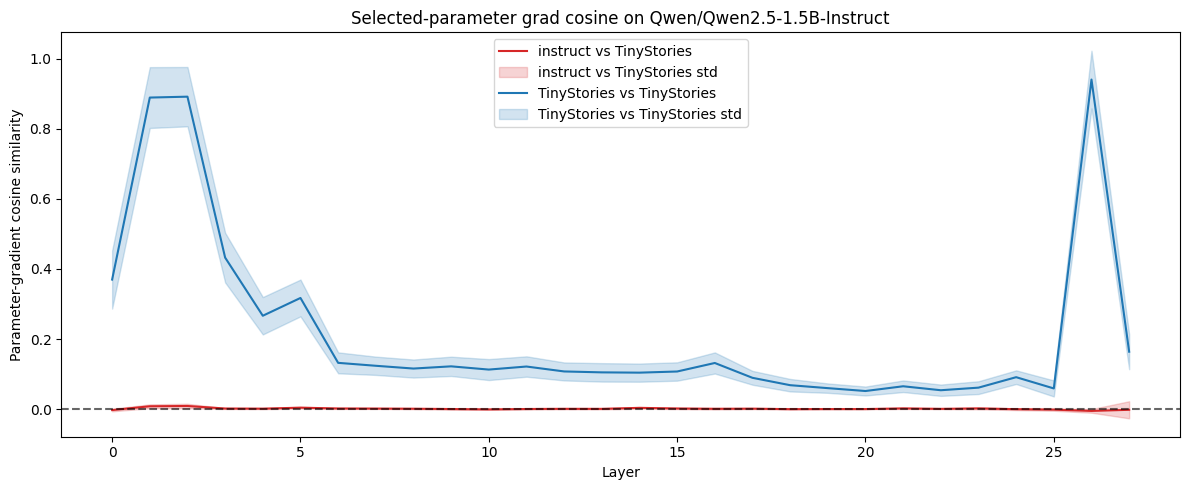

Most negative instruct-vs-TinyStories parameter-gradient layers:
layer=26 cross_mean=-0.0053 cross_std=0.0051 normal_mean=0.9407 modules=['attn.o_proj', 'mlp.down_proj']
layer=00 cross_mean=-0.0030 cross_std=0.0035 normal_mean=0.3697 modules=['attn.o_proj', 'mlp.down_proj']
layer=27 cross_mean=-0.0021 cross_std=0.0244 normal_mean=0.1637 modules=['attn.o_proj', 'mlp.down_proj']
layer=25 cross_mean=-0.0016 cross_std=0.0032 normal_mean=0.0588 modules=['attn.o_proj', 'mlp.down_proj']
layer=10 cross_mean=-0.0010 cross_std=0.0010 normal_mean=0.1127 modules=['attn.o_proj', 'mlp.down_proj']
layer=24 cross_mean=-0.0004 cross_std=0.0026 normal_mean=0.0910 modules=['attn.o_proj', 'mlp.down_proj']
layer=18 cross_mean=-0.0003 cross_std=0.0012 normal_mean=0.0681 modules=['attn.o_proj', 'mlp.down_proj']
layer=20 cross_mean=-0.0001 cross_std=0.0005 normal_mean=0.0515 modules=['attn.o_proj', 'mlp.down_proj']
layer=19 cross_mean=-0.0000 cross_std=0.0007 normal_mean=0.0597 modules=['attn.o_proj', 'mlp.do

In [9]:
# Follow-up: TinyStories as the normal distribution + parameter-gradient cosine on selected modules
import gc
import numpy as np
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoModelForCausalLM

if "tokenizer" not in globals():
    raise RuntimeError("Run the previous large-model gradient-cosine cell first so tokenizer/model_id are available.")

PARAM_MODEL_ID = model_id if "model_id" in globals() else "Qwen/Qwen2.5-1.5B-Instruct"
PARAM_BATCH_SIZE = 2
PARAM_N_PROBES = 16
PARAM_N_NORMAL_BATCHES = 3
PARAM_MAX_LENGTH = 160
PARAM_N_TINYSTORIES_TEXTS = 192
PROMPT_PREVIEW_CHARS = 240


def load_param_grad_model(model_name):
    compute_dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else (torch.float16 if torch.cuda.is_available() else torch.float32)
    kwargs = dict(
        trust_remote_code=True,
        low_cpu_mem_usage=True,
        cache_dir=HF_TMP_CACHE,
        dtype=compute_dtype,
    )
    if torch.cuda.is_available():
        kwargs["device_map"] = "auto"

    model_obj = AutoModelForCausalLM.from_pretrained(model_name, **kwargs)
    model_obj.eval()
    model_obj.config.use_cache = False
    return model_obj


def get_transformer_blocks_any(model_obj):
    if hasattr(model_obj, "model") and hasattr(model_obj.model, "layers"):
        return list(model_obj.model.layers)
    if hasattr(model_obj, "transformer") and hasattr(model_obj.transformer, "h"):
        return list(model_obj.transformer.h)
    raise AttributeError("Could not find transformer blocks on this model")


def get_target_modules(block):
    modules = []
    if hasattr(block, "self_attn") and hasattr(block.self_attn, "o_proj"):
        modules.append(("attn.o_proj", block.self_attn.o_proj))
    elif hasattr(block, "attn") and hasattr(block.attn, "c_proj"):
        modules.append(("attn.c_proj", block.attn.c_proj))

    if hasattr(block, "mlp"):
        for name in ["down_proj", "c_proj", "fc2"]:
            if hasattr(block.mlp, name):
                modules.append((f"mlp.{name}", getattr(block.mlp, name)))
                break
    return modules


def freeze_all_but_targets(model_obj):
    for p in model_obj.parameters():
        p.requires_grad_(False)

    blocks = get_transformer_blocks_any(model_obj)
    target_names = []
    for li, block in enumerate(blocks):
        mods = get_target_modules(block)
        target_names.append([name for name, _ in mods])
        for _, mod in mods:
            for p in mod.parameters():
                p.requires_grad_(True)
    return target_names


def gather_tinystories_normal_texts(n_texts):
    ds = load_dataset(
        "roneneldan/TinyStories",
        split="validation",
        cache_dir=os.environ["HF_DATASETS_CACHE"],
    )
    texts = []
    for ex in ds:
        text = ex["text"].strip()
        if len(text) < 80:
            continue
        texts.append(text)
        if len(texts) >= n_texts:
            break
    print(f"Collected TinyStories normal texts: {len(texts)}")
    return texts


def print_followup_previews(instruct_pool, normal_pool, n_show=2):
    print("\n=== Instruct prompt previews (follow-up) ===")
    for i, text in enumerate(instruct_pool[:n_show], start=1):
        print(f"[{i}] {text[:PROMPT_PREVIEW_CHARS].replace(chr(10), ' ')}")
        print("-" * 100)

    print("\n=== TinyStories prompt previews ===")
    for i, text in enumerate(normal_pool[:n_show], start=1):
        print(f"[{i}] {text[:PROMPT_PREVIEW_CHARS].replace(chr(10), ' ')}")
        print("-" * 100)


def sample_text_batch(texts, batch_size):
    replace = len(texts) < batch_size
    idx = np.random.choice(len(texts), size=batch_size, replace=replace)
    return [texts[int(i)] for i in idx]


def cos_safe(a, b, eps=1e-12):
    if a is None or b is None:
        return float("nan")
    an = torch.linalg.norm(a)
    bn = torch.linalg.norm(b)
    if float(an) < eps or float(bn) < eps:
        return float("nan")
    return float(torch.dot(a, b) / (an * bn))


def layer_parameter_grad_vectors(model_obj, tokenizer_obj, texts, max_length):
    blocks = get_transformer_blocks_any(model_obj)
    enc = tokenizer_obj(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=max_length,
    )
    input_device = model_obj.get_input_embeddings().weight.device
    enc = {k: v.to(input_device) for k, v in enc.items()}
    labels = enc["input_ids"].clone()
    labels[enc["attention_mask"] == 0] = -100

    model_obj.zero_grad(set_to_none=True)
    outputs = model_obj(**enc, labels=labels, use_cache=False)
    loss = outputs.loss
    loss.backward()

    vecs = []
    for block in blocks:
        parts = []
        for _, mod in get_target_modules(block):
            for p in mod.parameters():
                if p.requires_grad and p.grad is not None:
                    parts.append(p.grad.detach().reshape(-1).float().cpu())
        vecs.append(torch.cat(parts) if parts else None)

    model_obj.zero_grad(set_to_none=True)
    return vecs, float(loss.item())


def run_param_grad_cossim_probe(model_obj, tokenizer_obj, instruct_pool, normal_pool):
    instruct_batch = sample_text_batch(instruct_pool, PARAM_BATCH_SIZE)
    instruct_vecs, instruct_loss = layer_parameter_grad_vectors(
        model_obj, tokenizer_obj, instruct_batch, PARAM_MAX_LENGTH
    )

    normal_vec_sets = []
    normal_losses = []
    for _ in range(PARAM_N_NORMAL_BATCHES):
        normal_batch = sample_text_batch(normal_pool, PARAM_BATCH_SIZE)
        vecs, loss = layer_parameter_grad_vectors(
            model_obj, tokenizer_obj, normal_batch, PARAM_MAX_LENGTH
        )
        normal_vec_sets.append(vecs)
        normal_losses.append(loss)

    n_layers = len(instruct_vecs)
    instruct_vs_normal = []
    normal_vs_normal = []
    for layer_idx in range(n_layers):
        cross_vals = []
        for vecs in normal_vec_sets:
            v = cos_safe(instruct_vecs[layer_idx], vecs[layer_idx])
            if np.isfinite(v):
                cross_vals.append(v)
        instruct_vs_normal.append(float(np.mean(cross_vals)) if cross_vals else float("nan"))

        pair_vals = []
        for i in range(len(normal_vec_sets)):
            for j in range(i + 1, len(normal_vec_sets)):
                v = cos_safe(normal_vec_sets[i][layer_idx], normal_vec_sets[j][layer_idx])
                if np.isfinite(v):
                    pair_vals.append(v)
        normal_vs_normal.append(float(np.mean(pair_vals)) if pair_vals else float("nan"))

    return {
        "instruct_vs_normal": np.asarray(instruct_vs_normal, dtype=np.float32),
        "normal_vs_normal": np.asarray(normal_vs_normal, dtype=np.float32),
        "instruct_loss": instruct_loss,
        "normal_loss": float(np.mean(normal_losses)),
    }


param_model = load_param_grad_model(PARAM_MODEL_ID)
target_names = freeze_all_but_targets(param_model)
print(f"Loaded parameter-gradient model: {PARAM_MODEL_ID}")
print(f"Tracking modules per layer (example first 3 layers): {target_names[:3]}")

followup_instruct_texts = instruct_texts if "instruct_texts" in globals() else []
if len(followup_instruct_texts) == 0:
    raise RuntimeError("Expected instruct_texts from the previous cell.")
followup_normal_texts = gather_tinystories_normal_texts(PARAM_N_TINYSTORIES_TEXTS)
print_followup_previews(followup_instruct_texts, followup_normal_texts, n_show=2)
print(
    f"\nRunning parameter-gradient probe with BATCH_SIZE={PARAM_BATCH_SIZE}, "
    f"N_PROBES={PARAM_N_PROBES}, N_NORMAL_BATCHES={PARAM_N_NORMAL_BATCHES}, "
    f"MAX_LENGTH={PARAM_MAX_LENGTH}"
)

param_probe_results = []
for probe_idx in range(PARAM_N_PROBES):
    result = run_param_grad_cossim_probe(
        param_model, tokenizer, followup_instruct_texts, followup_normal_texts
    )
    param_probe_results.append(result)
    if (probe_idx + 1) % 4 == 0 or probe_idx == 0 or probe_idx + 1 == PARAM_N_PROBES:
        print(
            f"probe={probe_idx + 1}/{PARAM_N_PROBES} "
            f"instruct_loss={result['instruct_loss']:.4f} "
            f"normal_loss={result['normal_loss']:.4f}"
        )

param_cross = np.stack([r["instruct_vs_normal"] for r in param_probe_results], axis=0)
param_normal = np.stack([r["normal_vs_normal"] for r in param_probe_results], axis=0)
param_layers = np.arange(param_cross.shape[1])

param_cross_mean = np.nanmean(param_cross, axis=0)
param_cross_std = np.nanstd(param_cross, axis=0)
param_normal_mean = np.nanmean(param_normal, axis=0)
param_normal_std = np.nanstd(param_normal, axis=0)

plt.figure(figsize=(12, 5))
plt.plot(param_layers, param_cross_mean, label="instruct vs TinyStories", color="tab:red")
plt.fill_between(
    param_layers,
    param_cross_mean - param_cross_std,
    param_cross_mean + param_cross_std,
    color="tab:red",
    alpha=0.2,
    label="instruct vs TinyStories std",
)
plt.plot(param_layers, param_normal_mean, label="TinyStories vs TinyStories", color="tab:blue")
plt.fill_between(
    param_layers,
    param_normal_mean - param_normal_std,
    param_normal_mean + param_normal_std,
    color="tab:blue",
    alpha=0.2,
    label="TinyStories vs TinyStories std",
)
plt.axhline(0.0, color="k", linestyle="--", alpha=0.6)
plt.xlabel("Layer")
plt.ylabel("Parameter-gradient cosine similarity")
plt.title(f"Selected-parameter grad cosine on {PARAM_MODEL_ID}")
plt.legend()
plt.tight_layout()
plt.show()

most_negative_param = np.argsort(param_cross_mean)[:10]
print("Most negative instruct-vs-TinyStories parameter-gradient layers:")
for idx in most_negative_param:
    print(
        f"layer={int(idx):02d} "
        f"cross_mean={param_cross_mean[idx]:.4f} cross_std={param_cross_std[idx]:.4f} "
        f"normal_mean={param_normal_mean[idx]:.4f} modules={target_names[int(idx)]}"
    )

del param_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()